# Interpolation

Interpolation der Spektren auf die Messzeitpunkte aus `read and plot.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "Daten final").exists():
            return path
    raise FileNotFoundError("Projektordner mit data/Daten final wurde nicht gefunden.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "Daten final"

# Auswahl: hier Material, Temperatur und Mode einstellen.
MATERIAL = "PEI5mgmL"
TEMPERATURE = "50°C"
MODE = "Abs"
INTERPOLATED_VALUE_COLS = ("Eps_real",)
PLOT_TIME_S = 0
TIME_COL = "Time_Relative_s"

SELECTED_FILE = f"{MATERIAL}_{TEMPERATURE}_{MODE}.TXT"
DATA_DIR / SELECTED_FILE


WindowsPath('c:/Users/Max/Documents/bachelor thesis/data/Daten final/PEI5mgmL_50°C_Abs.TXT')

## Daten laden

Die Dateien werden wie in `read and plot.ipynb` eingelesen. `Spectrum_ID` zaehlt die nacheinander aufgenommenen Rohspektren.

In [3]:
COLUMNS = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi",
]

# Hier die manuell abgelesene Punktnummer des Atmosphaerenwechsels je Reihe eintragen.
# Die Punktnummer bezeichnet den Messpunkt direkt vor dem Wechsel; t=0 wird zwischen
# diesem Punkt und dem darauffolgenden Punkt gesetzt.
manual_switch_points = {
    ("PEI2mgmL", "50°C", "Abs"): 132,
    ("PEI2mgmL", "50°C", "Des"): 145,
    ("PEI2mgmL", "90°C", "Abs"): 151,
    ("PEI2mgmL", "90°C", "Des"): 152,
    ("PEI5mgmL", "50°C", "Abs"): 127,
    ("PEI5mgmL", "50°C", "Des"): 145,
    ("PEI5mgmL", "60°C", "Abs"): 127,
    ("PEI5mgmL", "60°C", "Des"): 145,
    ("PEI5mgmL", "70°C", "Abs"): 127,
    ("PEI5mgmL", "70°C", "Des"): 145,
    ("PEI5mgmL", "80°C", "Abs"): 128,
    ("PEI5mgmL", "80°C", "Des"): 128,
    ("PEI5mgmL", "90°C", "Abs"): 128,
    ("PEI5mgmL", "90°C", "Des"): 128,
}


def load_measurements(data_dir=DATA_DIR, selected_file=None):
    if selected_file is None:
        file_paths = sorted(list(data_dir.glob("*.TXT")) + list(data_dir.glob("*.txt")))
    else:
        file_path = data_dir / selected_file
        if not file_path.exists():
            raise FileNotFoundError(f"Datei nicht gefunden: {file_path}")
        file_paths = [file_path]

    if not file_paths:
        raise FileNotFoundError(f"Keine .TXT-Dateien gefunden in: {data_dir}")

    dfs = []
    for path in file_paths:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            skiprows=4,
            names=COLUMNS,
            encoding="latin1",
            engine="python",
        )

        parts = path.stem.split("_")
        if len(parts) >= 3:
            material, temperature, mode = parts[:3]
        else:
            material, temperature, mode = path.stem, None, None

        first_freq = df["Freq_Hz"].iloc[0]
        df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
        df["Spectrum_Number"] = df["Spectrum_ID"] + 1
        df["Point_Number"] = range(1, len(df) + 1)
        df["Material"] = material
        df["Temperature"] = temperature
        df["Mode"] = mode
        df["Source_File"] = path.name

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def add_relative_switch_time(df, switch_points):
    df = df.copy()
    switch_time_rows = []

    for dataset_key, dataset in df.groupby(["Material", "Temperature", "Mode"], dropna=False):
        switch_point_number = switch_points.get(dataset_key)
        if switch_point_number is None:
            raise ValueError(
                "Fuer diese Reihe fehlt eine Switch_Point_Number: "
                f"Material={dataset_key[0]}, Temperature={dataset_key[1]}, Mode={dataset_key[2]}"
            )

        switch_point = dataset[dataset["Point_Number"] == switch_point_number]
        next_point = dataset[dataset["Point_Number"] == switch_point_number + 1]

        if switch_point.empty or next_point.empty:
            raise ValueError(
                "Der Atmosphaerenwechsel muss zwischen zwei vorhandenen Messpunkten liegen: "
                f"Material={dataset_key[0]}, Temperature={dataset_key[1]}, Mode={dataset_key[2]}, "
                f"Switch_Point_Number={switch_point_number}"
            )

        switch_time = float(
            (switch_point["MTime_s"].iloc[0] + next_point["MTime_s"].iloc[0]) / 2
        )
        switch_spectrum_id = int(switch_point["Spectrum_ID"].iloc[0])

        switch_time_rows.append(
            {
                "Material": dataset_key[0],
                "Temperature": dataset_key[1],
                "Mode": dataset_key[2],
                "Switch_Point_Number": int(switch_point_number),
                "Switch_Spectrum_ID": switch_spectrum_id,
                "Switch_Time_s": switch_time,
            }
        )

    switch_times = pd.DataFrame(switch_time_rows)
    df = df.merge(switch_times, on=["Material", "Temperature", "Mode"], how="left")
    df["Time_Relative_s"] = df["MTime_s"] - df["Switch_Time_s"]
    return df, switch_times


df_all = load_measurements(selected_file=SELECTED_FILE)
df_all, switch_times = add_relative_switch_time(df_all, manual_switch_points)
switch_times


,Material,Temperature,Mode,Switch_Point_Number,Switch_Spectrum_ID,Switch_Time_s
0,PEI5mgmL,50°C,Abs,127,5,420.43


## Vollstaendige Spektren interpolieren

Fuer jede Datei werden alle gemessenen relativen Zeitpunkte gesammelt und `t_rel = 0` als eigener Zielzeitpunkt eingefuegt. Fuer normale Zielzeitpunkte wird jede Frequenz linear entlang der Zeit interpoliert.

Am Atmosphaerenwechsel wird pro Frequenz zuerst ein zusaetzlicher Punkt bei `t_rel = 0` eingesetzt: Die Gerade durch die zwei gemessenen Punkte links von `t=0` wird bis `t=0` fortgesetzt. Dieser eingesetzte Punkt ist danach ein normaler Stuetzpunkt der Interpolation, sodass rechts von `t=0` bis zum naechsten Messpunkt gegen diesen eingesetzten Punkt interpoliert wird.


In [4]:
def _linear_at(target_time, times, values):
    if len(times) < 2:
        return np.nan
    x0, x1 = float(times[0]), float(times[1])
    y0, y1 = float(values[0]), float(values[1])
    if x0 == x1:
        return np.nan
    return y0 + (target_time - x0) * (y1 - y0) / (x1 - x0)


def _insert_switch_support_point(freq_data, value_col, time_col=TIME_COL, target_time=0):
    before = freq_data[freq_data[time_col] < target_time].tail(2)
    if len(before) < 2:
        return freq_data[[time_col, value_col]].dropna().sort_values(time_col)

    switch_value = _linear_at(
        target_time,
        before[time_col].to_numpy(),
        before[value_col].to_numpy(),
    )

    support_points = freq_data[[time_col, value_col]].dropna().copy()
    support_points = support_points[~np.isclose(support_points[time_col], target_time)]
    support_points = pd.concat(
        [
            support_points,
            pd.DataFrame({time_col: [float(target_time)], value_col: [switch_value]}),
        ],
        ignore_index=True,
    )
    support_points = support_points.sort_values(time_col)
    return support_points.groupby(time_col, as_index=False)[value_col].mean()


def interpolate_complete_spectra(
    df,
    time_col=TIME_COL,
    freq_col="Freq_Hz",
    value_cols=INTERPOLATED_VALUE_COLS,
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    drop_incomplete=True,
    include_switch_time=True,
):
    rows = []
    metadata_cols = ["Switch_Point_Number", "Switch_Spectrum_ID", "Switch_Time_s"]

    for dataset_key, dataset in df.groupby(list(dataset_cols), dropna=False):
        dataset_meta = dict(zip(dataset_cols, dataset_key if isinstance(dataset_key, tuple) else (dataset_key,)))
        target_times = np.sort(dataset[time_col].dropna().unique())
        if include_switch_time and not np.isclose(target_times, 0).any():
            target_times = np.sort(np.append(target_times, 0.0))

        frequencies = np.sort(dataset[freq_col].dropna().unique())
        dataset_metadata = {
            col: dataset[col].dropna().iloc[0]
            for col in metadata_cols
            if col in dataset.columns and not dataset[col].dropna().empty
        }

        interpolated_by_freq = {}
        for freq in frequencies:
            needed_cols = [time_col, freq_col, "Spectrum_ID", *metadata_cols, *value_cols]
            freq_data = (
                dataset.loc[dataset[freq_col] == freq, [col for col in needed_cols if col in dataset.columns]]
                .dropna(subset=[time_col])
                .sort_values(time_col)
            )

            grouped_values = {value_col: "mean" for value_col in value_cols}
            grouped_values.update({"Spectrum_ID": "first"})
            for col in metadata_cols:
                if col in freq_data.columns:
                    grouped_values[col] = "first"
            freq_data = freq_data.groupby(time_col, as_index=False).agg(grouped_values)

            interpolated_values = {}
            for value_col in value_cols:
                support_points = _insert_switch_support_point(
                    freq_data,
                    value_col,
                    time_col=time_col,
                    target_time=0,
                )
                support_times = support_points[time_col].to_numpy()
                support_values = support_points[value_col].to_numpy()

                interpolated_values[value_col] = np.interp(
                    target_times,
                    support_times,
                    support_values,
                    left=np.nan,
                    right=np.nan,
                )

            interpolated_by_freq[freq] = interpolated_values

        for spectrum_id, target_time in enumerate(target_times):
            for freq in frequencies:
                row = {
                    **dataset_meta,
                    **dataset_metadata,
                    "Interpolated_Spectrum_ID": spectrum_id,
                    time_col: target_time,
                    freq_col: freq,
                    "Is_Switch_Spectrum": bool(np.isclose(target_time, 0)),
                }
                for value_col in value_cols:
                    row[value_col] = interpolated_by_freq[freq][value_col][spectrum_id]
                rows.append(row)

    interpolated = pd.DataFrame(rows)

    if drop_incomplete:
        complete_ids = [*dataset_cols, "Interpolated_Spectrum_ID"]
        complete_mask = interpolated.groupby(complete_ids, dropna=False)[list(value_cols)].transform(
            lambda values: values.notna().all()
        )
        interpolated = interpolated[complete_mask.all(axis=1)].reset_index(drop=True)

    return interpolated


df_interpolated_complete = interpolate_complete_spectra(df_all)
df_interpolated_complete[df_interpolated_complete["Is_Switch_Spectrum"]].head()


,Source_File,Material,Temperature,Mode,Switch_Point_Number,Switch_Spectrum_ID,Switch_Time_s,Interpolated_Spectrum_ID,Time_Relative_s,Freq_Hz,Is_Switch_Spectrum,Eps_real
2496,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,100.00,True,6.215676
2497,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,150.00,True,6.175619
2498,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,225.00,True,6.150318
2499,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,337.50,True,6.119042
2500,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,506.25,True,6.087711


## Ableitung bilden

Nach der Interpolation wird epsilon' entlang der Frequenzachse abgeleitet: `-pi/2 * d epsilon' / d ln(omega)`.

In [5]:
def derive_eps_real_by_frequency(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Interpolated_Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col, time_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col)
        frequencies = spectrum[freq_col].to_numpy()
        eps_real = spectrum[value_col].to_numpy()

        omega = 2 * np.pi * frequencies
        ln_omega = np.log(omega)
        derivative = -np.pi / 2 * np.diff(eps_real) / np.diff(ln_omega)
        omega_mid = np.exp((ln_omega[:-1] + ln_omega[1:]) / 2)
        freq_mid = omega_mid / (2 * np.pi)

        meta = dict(zip(group_cols, group_key if isinstance(group_key, tuple) else (group_key,)))
        for freq, omega_value, derivative_value in zip(freq_mid, omega_mid, derivative):
            rows.append({
                **meta,
                "Freq_Hz_mid": freq,
                "Omega_rad_s": omega_value,
                "Eps_real_derivative": derivative_value,
            })

    return pd.DataFrame(rows)


df_derivative = derive_eps_real_by_frequency(df_interpolated_complete)
df_derivative.head()


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,Freq_Hz_mid,Omega_rad_s,Eps_real_derivative
0,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,122.474487,769.529898,0.132381
1,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,183.711731,1154.294847,0.119029
2,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,275.567596,1731.442271,0.118800
3,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,413.351394,2597.163406,0.123492
4,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,620.029132,3895.757935,0.132204


## Rohdaten ableiten

Zum Vergleich mit der Interpolation wird epsilon' auch direkt fuer die urspruenglichen Rohspektren entlang der Frequenzachse abgeleitet.

In [6]:
def derive_raw_eps_real_by_frequency(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col)
        frequencies = spectrum[freq_col].to_numpy()
        eps_real = spectrum[value_col].to_numpy()
        times = spectrum[time_col].to_numpy()

        if len(frequencies) < 2:
            continue

        omega = 2 * np.pi * frequencies
        ln_omega = np.log(omega)
        derivative = -np.pi / 2 * np.diff(eps_real) / np.diff(ln_omega)
        omega_mid = np.exp((ln_omega[:-1] + ln_omega[1:]) / 2)
        freq_mid = omega_mid / (2 * np.pi)
        time_mid = (times[:-1] + times[1:]) / 2
        spectrum_time = np.nanmedian(times)

        meta = dict(zip(group_cols, group_key if isinstance(group_key, tuple) else (group_key,)))
        for freq, omega_value, time_value, derivative_value in zip(freq_mid, omega_mid, time_mid, derivative):
            rows.append({
                **meta,
                "Freq_Hz_mid": freq,
                "Omega_rad_s": omega_value,
                "Raw_Time_Relative_s": time_value,
                "Spectrum_Time_Relative_s": spectrum_time,
                "Eps_real_derivative_raw": derivative_value,
            })

    return pd.DataFrame(rows)


df_raw_derivative = derive_raw_eps_real_by_frequency(df_all)
df_raw_derivative.head()


,Source_File,Material,Temperature,Mode,Spectrum_ID,Freq_Hz_mid,Omega_rad_s,Raw_Time_Relative_s,Spectrum_Time_Relative_s,Eps_real_derivative_raw
0,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,0,122.474487,769.529898,-411.380,-380.03,0.127844
1,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,0,183.711731,1154.294847,-408.700,-380.03,0.124745
2,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,0,275.567596,1731.442271,-405.775,-380.03,0.120483
3,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,0,413.351394,2597.163406,-402.995,-380.03,0.121258
4,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,0,620.029132,3895.757935,-400.355,-380.03,0.132878


In [7]:
summary = (
    df_interpolated_complete.groupby(["Source_File", "Material", "Temperature", "Mode"], dropna=False)
    .agg(
        spectra=("Interpolated_Spectrum_ID", "nunique"),
        frequencies=("Freq_Hz", "nunique"),
        first_time_relative_s=("Time_Relative_s", "min"),
        last_time_relative_s=("Time_Relative_s", "max"),
        switch_spectra=("Is_Switch_Spectrum", "sum"),
    )
    .reset_index()
)
summary


,Source_File,Material,Temperature,Mode,spectra,frequencies,first_time_relative_s,last_time_relative_s,switch_spectra
0,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,2859,24,-340.5,8954.47,24


## Zeitverlauf der Stufenhoehe

Fuer jede Messreihe wird aus den interpolierten Spektren die Stufenhoehe von `eps_real` berechnet. Dazu wird jedes Spektrum nach Frequenz sortiert und die Differenz zwischen dem ersten Wert und dem viertletzten Wert gebildet; die letzten drei Frequenzpunkte werden ignoriert.


In [8]:
def calculate_eps_real_step_height(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Interpolated_Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    ignored_last_points=3,
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col, time_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col).reset_index(drop=True)
        if len(spectrum) <= ignored_last_points:
            continue

        first = spectrum.iloc[0]
        comparison = spectrum.iloc[-(ignored_last_points + 1)]
        meta = dict(zip(group_cols, group_key if isinstance(group_key, tuple) else (group_key,)))

        rows.append(
            {
                **meta,
                "First_Freq_Hz": first[freq_col],
                "Comparison_Freq_Hz": comparison[freq_col],
                "First_Eps_real": first[value_col],
                "Comparison_Eps_real": comparison[value_col],
                "Eps_real_Step_Height": first[value_col] - comparison[value_col],
            }
        )

    return pd.DataFrame(rows).sort_values([*dataset_cols, time_col]).reset_index(drop=True)


# Fuer die Stufenhoehen werden alle Messreihen ausgewertet, nicht nur SELECTED_FILE.
df_all_series = load_measurements(selected_file=None)
df_all_series, switch_times_all_series = add_relative_switch_time(df_all_series, manual_switch_points)
df_interpolated_all_series = interpolate_complete_spectra(df_all_series)
df_eps_real_step_height = calculate_eps_real_step_height(df_interpolated_all_series)

df_eps_real_step_height.head()


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,First_Freq_Hz,Comparison_Freq_Hz,First_Eps_real,Comparison_Eps_real,Eps_real_Step_Height
0,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,23,-372.255,100.0,332530.0,1.833750,1.542309,0.291440
1,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,24,-362.725,100.0,332530.0,1.833900,1.542321,0.291579
2,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,25,-360.285,100.0,332530.0,1.833888,1.542324,0.291564
3,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,26,-355.305,100.0,332530.0,1.833863,1.542330,0.291533
4,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,27,-352.625,100.0,332530.0,1.833850,1.542334,0.291517


## Beispielplot der Stufenhoehe

Der Plot zeigt den Zeitverlauf der Stufenhoehe fuer die ausgewaehlten Messreihen. In den Auswahlvariablen kann `None`, ein einzelner Wert oder eine Liste mehrerer Werte stehen.


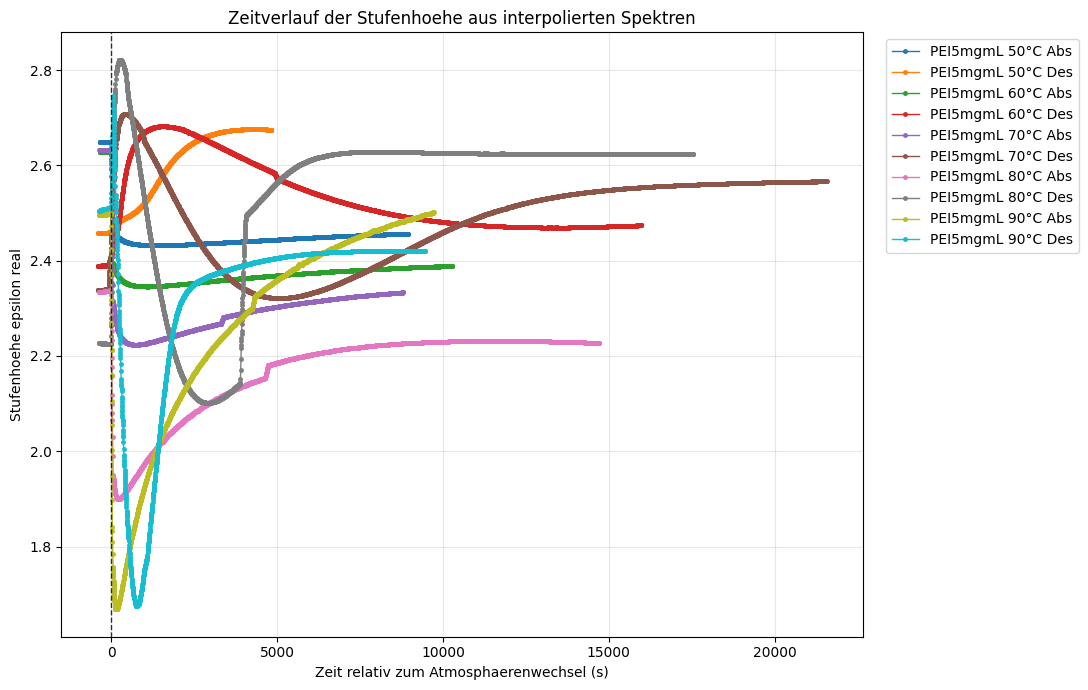

In [9]:
# Auswahl fuer den Plot:
# None = alle Werte anzeigen
# Einzelwert = z.B. "PEI5mgmL"
# Mehrere Werte = z.B. ["50°C", "90°C"]

STEP_HEIGHT_MATERIALS = ["PEI5mgmL"]      # None, "PEI5mgmL" oder ["PEI2mgmL", "PEI5mgmL"]
STEP_HEIGHT_TEMPERATURES = None            # None, "50°C" oder ["50°C", "90°C"]
STEP_HEIGHT_MODES = ["Abs", "Des"]        # None, "Abs", "Des" oder ["Abs", "Des"]


def _as_selection_list(selection):
    if selection is None:
        return None
    if isinstance(selection, str):
        return [selection]
    return list(selection)


plot_df = df_eps_real_step_height.copy()

selection_filters = {
    "Material": _as_selection_list(STEP_HEIGHT_MATERIALS),
    "Temperature": _as_selection_list(STEP_HEIGHT_TEMPERATURES),
    "Mode": _as_selection_list(STEP_HEIGHT_MODES),
}

for column, allowed_values in selection_filters.items():
    if allowed_values is not None:
        plot_df = plot_df[plot_df[column].isin(allowed_values)]

if plot_df.empty:
    available = df_eps_real_step_height[["Material", "Temperature", "Mode"]].drop_duplicates()
    raise ValueError(
        "Keine Stufenhoehen-Daten fuer diese Auswahl gefunden. Verfuegbare Reihen:\n"
        + available.to_string(index=False)
    )

plt.figure(figsize=(11, 7))

for keys, series in plot_df.groupby(["Material", "Temperature", "Mode"], dropna=False):
    material, temp, mode = keys
    series = series.sort_values(TIME_COL)
    plt.plot(
        series[TIME_COL],
        series["Eps_real_Step_Height"],
        marker="o",
        markersize=2.5,
        linewidth=1,
        label=f"{material} {temp} {mode}",
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
plt.xlabel("Zeit relativ zum Atmosphaerenwechsel (s)")
plt.ylabel("Stufenhoehe epsilon real")
plt.title("Zeitverlauf der Stufenhoehe aus interpolierten Spektren")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Beispielplot

Ein interpoliertes Spektrum wird gegen die Frequenz geplottet.

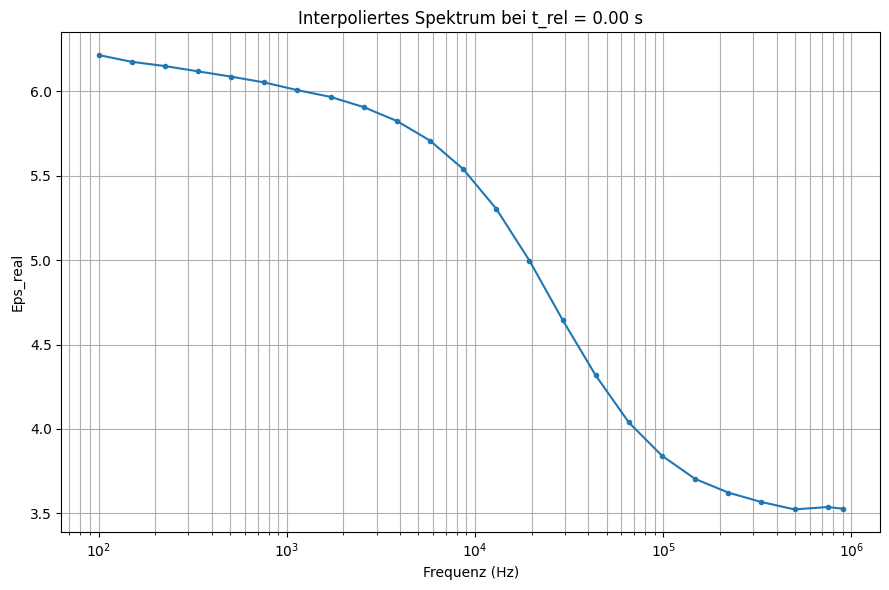

In [10]:
temp = TEMPERATURE
material = MATERIAL
mode = MODE
y_col = "Eps_real"

plot_base = df_interpolated_complete[
    (df_interpolated_complete["Temperature"] == temp)
    & (df_interpolated_complete["Material"] == material)
    & (df_interpolated_complete["Mode"] == mode)
]

if plot_base.empty:
    raise ValueError("Keine interpolierten Daten fuer diese Auswahl gefunden.")

available_times = np.sort(plot_base[TIME_COL].unique())
plot_time = available_times[np.abs(available_times - PLOT_TIME_S).argmin()]
plot_df = plot_base[plot_base[TIME_COL] == plot_time].sort_values("Freq_Hz")

plt.figure(figsize=(9, 6))
plt.plot(plot_df["Freq_Hz"], plot_df[y_col], marker="o", markersize=3)
plt.xscale("log")
plt.xlabel("Frequenz (Hz)")
plt.ylabel(y_col)
plt.title(f"Interpoliertes Spektrum bei t_rel = {plot_time:.2f} s")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


## Beispielplot der Interpolation am Atmosphaerenwechsel

Geschlossene Punkte sind Rohmesspunkte, offene Punkte sind interpolierte Zeitpunkte. Das eingefuegte Spektrum bei `t_rel = 0` wird als gefuellte Raute markiert.


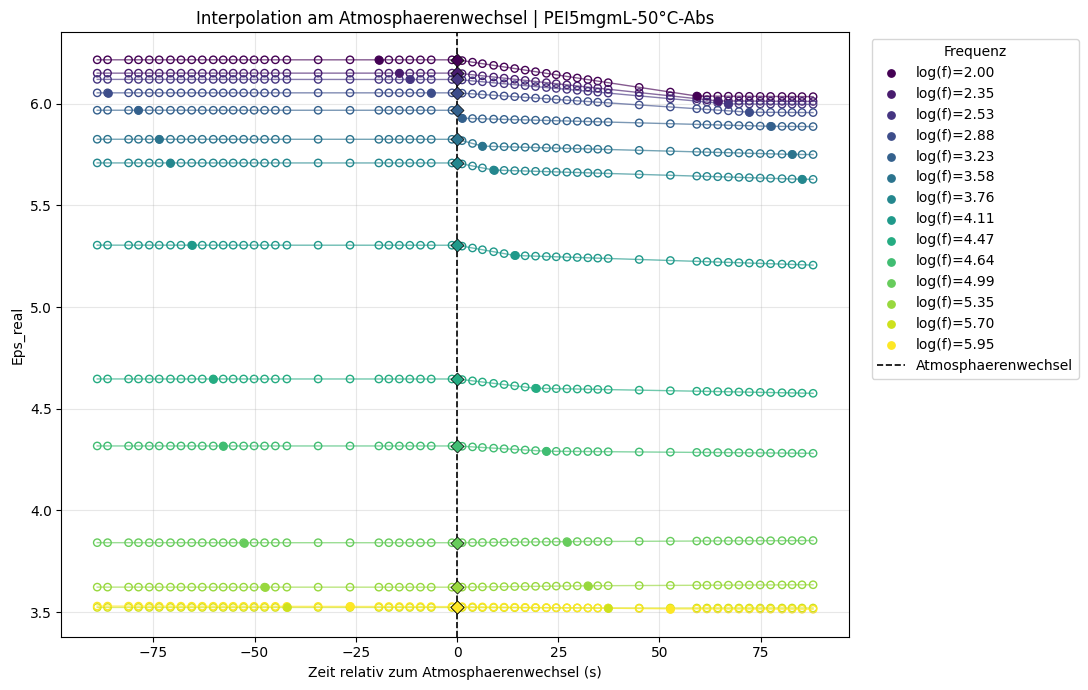

In [11]:
temp = TEMPERATURE
material = MATERIAL
mode = MODE
y_col = "Eps_real"

raw_base = df_all[
    (df_all["Temperature"] == temp)
    & (df_all["Material"] == material)
    & (df_all["Mode"] == mode)
].copy()
interpolated_base = df_interpolated_complete[
    (df_interpolated_complete["Temperature"] == temp)
    & (df_interpolated_complete["Material"] == material)
    & (df_interpolated_complete["Mode"] == mode)
].copy()

if raw_base.empty or interpolated_base.empty:
    raise ValueError("Keine Daten fuer diese Auswahl gefunden.")

plot_window_s = 90
raw_window = raw_base[raw_base[TIME_COL].between(-plot_window_s, plot_window_s)]
interpolated_window = interpolated_base[
    interpolated_base[TIME_COL].between(-plot_window_s, plot_window_s)
]
switch_spectrum = interpolated_base[interpolated_base["Is_Switch_Spectrum"]]

freqs_for_plot = np.geomspace(raw_base["Freq_Hz"].min(), raw_base["Freq_Hz"].max(), 14)
freqs_for_plot = np.array([
    raw_base.loc[(raw_base["Freq_Hz"] - freq).abs().idxmin(), "Freq_Hz"]
    for freq in freqs_for_plot
])
freqs_for_plot = np.unique(freqs_for_plot)
colors = plt.cm.viridis(np.linspace(0, 1, len(freqs_for_plot)))

plt.figure(figsize=(11, 7))

for freq, color in zip(freqs_for_plot, colors):
    raw_freq = raw_window[raw_window["Freq_Hz"] == freq].sort_values(TIME_COL)
    int_freq = interpolated_window[interpolated_window["Freq_Hz"] == freq].sort_values(TIME_COL)
    switch_freq = switch_spectrum[switch_spectrum["Freq_Hz"] == freq]
    label = f"log(f)={np.log10(freq):.2f}"

    plt.plot(
        int_freq[TIME_COL],
        int_freq[y_col],
        color=color,
        linewidth=1,
        alpha=0.65,
    )
    plt.scatter(
        int_freq[TIME_COL],
        int_freq[y_col],
        facecolors="none",
        edgecolors=[color],
        s=28,
        linewidths=1,
    )
    plt.scatter(
        raw_freq[TIME_COL],
        raw_freq[y_col],
        color=color,
        s=28,
        label=label,
        zorder=3,
    )
    if not switch_freq.empty:
        plt.scatter(
            switch_freq[TIME_COL],
            switch_freq[y_col],
            color=color,
            marker="D",
            s=44,
            edgecolors="black",
            linewidths=0.5,
            zorder=4,
        )

plt.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Atmosphaerenwechsel")
plt.xlabel("Zeit relativ zum Atmosphaerenwechsel (s)")
plt.ylabel(y_col)
plt.title(f"Interpolation am Atmosphaerenwechsel | {material}-{temp}-{mode}")
plt.grid(True, alpha=0.3)
plt.legend(title="Frequenz", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Beispielplot der Ableitung

Ein abgeleitetes interpoliertes Spektrum wird gegen die Kreisfrequenz geplottet.

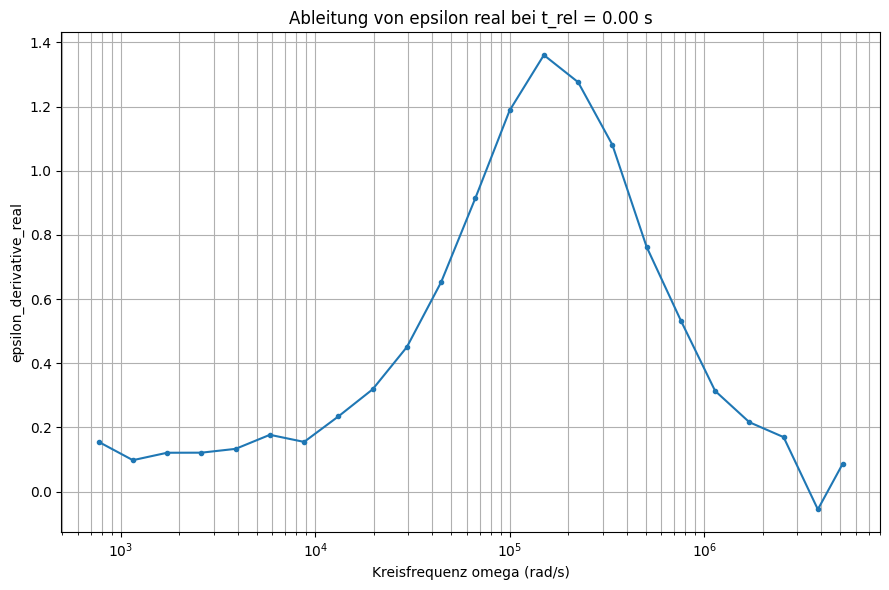

In [12]:
temp = TEMPERATURE
material = MATERIAL
mode = MODE
y_col = "Eps_real_derivative"

plot_base = df_derivative[
    (df_derivative["Temperature"] == temp)
    & (df_derivative["Material"] == material)
    & (df_derivative["Mode"] == mode)
]

if plot_base.empty:
    raise ValueError("Keine abgeleiteten Daten fuer diese Auswahl gefunden.")

available_times = np.sort(plot_base[TIME_COL].unique())
plot_time = available_times[np.abs(available_times - PLOT_TIME_S).argmin()]
plot_df = plot_base[plot_base[TIME_COL] == plot_time].sort_values("Omega_rad_s")

plt.figure(figsize=(9, 6))
plt.plot(plot_df["Omega_rad_s"], plot_df[y_col], marker="o", markersize=3)
plt.xscale("log")
plt.xlabel("Kreisfrequenz omega (rad/s)")
plt.ylabel("epsilon_derivative_real")
plt.title(f"Ableitung von epsilon real bei t_rel = {plot_time:.2f} s")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


## Rohdaten vs. Interpolation

Die interpolierte Ableitung wird zusammen mit dem zeitlich naechstgelegenen urspruenglichen Rohspektrum geplottet.

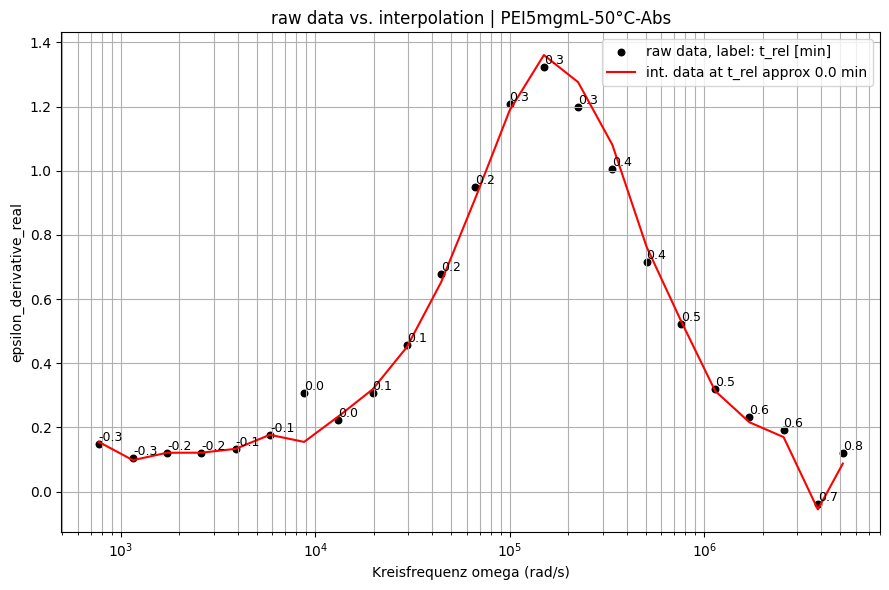

In [13]:
temp = TEMPERATURE
material = MATERIAL
mode = MODE

interpolated_base = df_derivative[
    (df_derivative["Temperature"] == temp)
    & (df_derivative["Material"] == material)
    & (df_derivative["Mode"] == mode)
]
raw_base = df_raw_derivative[
    (df_raw_derivative["Temperature"] == temp)
    & (df_raw_derivative["Material"] == material)
    & (df_raw_derivative["Mode"] == mode)
]

if interpolated_base.empty:
    raise ValueError("Keine interpolierten Ableitungsdaten fuer diese Auswahl gefunden.")
if raw_base.empty:
    raise ValueError("Keine Rohdaten-Ableitungen fuer diese Auswahl gefunden.")

available_times = np.sort(interpolated_base[TIME_COL].unique())
plot_time = available_times[np.abs(available_times - PLOT_TIME_S).argmin()]
interpolated_plot = interpolated_base[interpolated_base[TIME_COL] == plot_time].sort_values("Omega_rad_s")

raw_spectrum_times = raw_base[["Spectrum_ID", "Spectrum_Time_Relative_s"]].drop_duplicates()
nearest_raw_index = (raw_spectrum_times["Spectrum_Time_Relative_s"] - plot_time).abs().idxmin()
raw_spectrum_id = raw_spectrum_times.loc[nearest_raw_index, "Spectrum_ID"]
raw_time = raw_spectrum_times.loc[nearest_raw_index, "Spectrum_Time_Relative_s"]
raw_plot = raw_base[raw_base["Spectrum_ID"] == raw_spectrum_id].sort_values("Omega_rad_s")

plt.figure(figsize=(9, 6))
plt.scatter(
    raw_plot["Omega_rad_s"],
    raw_plot["Eps_real_derivative_raw"],
    color="black",
    s=22,
    label="raw data, label: t_rel [min]",
)
plt.plot(
    interpolated_plot["Omega_rad_s"],
    interpolated_plot["Eps_real_derivative"],
    color="red",
    label=f"int. data at t_rel approx {plot_time / 60:.1f} min",
)

for _, row in raw_plot.iterrows():
    raw_time_label = row["Raw_Time_Relative_s"] / 60
    plt.text(
        row["Omega_rad_s"],
        row["Eps_real_derivative_raw"],
        f"{raw_time_label:.1f}",
        fontsize=9,
        ha="left",
        va="bottom",
    )

if (raw_plot["Eps_real_derivative_raw"] > 0).all() and (interpolated_plot["Eps_real_derivative"] > 0).all():
    plt.yscale("log")
plt.xscale("log")
plt.xlabel("Kreisfrequenz omega (rad/s)")
plt.ylabel("epsilon_derivative_real")
plt.title(f"raw data vs. interpolation | {material}-{temp}-{mode}")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()
